## **Sistem Rekomendasi Destinasi Wisata di Indonesia Berbasis Content-Based Filtering**

## **Import Library**

In [26]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords


print("Semua library berhasil diimport")

Semua library berhasil diimport


## **Load Dataset**

In [27]:
file_path = "wisata_indonesia_final.csv"

try:
    df = pd.read_csv(file_path, encoding='ISO-8859-1')
    print(f"Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
except FileNotFoundError:
    print("File tidak ditemukan, membuat dataset contoh...")
    
    df = pd.DataFrame(sample_data)
    print(f"Dataset contoh berhasil dibuat: {df.shape[0]} baris")

print("\n5 data pertama:")
df.head()

Dataset berhasil dimuat: 1025 baris x 10 kolom

5 data pertama:


,kategori,nama_wisata,latitude,longitude,alamat,provinsi,kota_kabupaten,nama_lengkap,path_gambar,deskripsi_bersih
0,air terjun,Air Terjun Aling-Aling,-8.176792,115.106284,"Air Terjun Aling-Aling, Panji Anom, Buleleng, ...",Bali,Buleleng,"Air Terjun Aling-Aling, Buleleng, Bali",gambar_wisata/Air_Terjun_Aling-Aling,Deskripsi tidak ditemukan
1,air terjun,Air Terjun Bantimurung,-5.016520,119.685520,"Air Terjun Bantimurung, Jalan Poros Bantimurun...",Sulawesi Selatan,Sulawesi,"Air Terjun Bantimurung, Sulawesi, Sulawesi Sel...",gambar_wisata/Air_Terjun_Bantimurung,Air Terjun Bantimurung adalah salah satu air t...
2,air terjun,Air Terjun Benang Kelambu,-8.532770,116.337011,"Air Terjun Benang Kelambu, Pemotoh, Lombok Ten...",Nusa Tenggara Barat,Lombok Tengah,"Air Terjun Benang Kelambu, Lombok Tengah, Nusa...",gambar_wisata/Air_Terjun_Benang_Kelambu,Deskripsi tidak ditemukan
3,air terjun,Air Terjun Benang Stokel,-8.533036,116.341379,"Air Terjun Benang Stokel, Pemotoh, Lombok Teng...",Nusa Tenggara Barat,Lombok Tengah,"Air Terjun Benang Stokel, Lombok Tengah, Nusa ...",gambar_wisata/Air_Terjun_Benang_Stokel,Deskripsi tidak ditemukan
4,air terjun,Air Terjun Bidadari,-2.928361,107.839043,"Air Terjun Bidadari, Nyuruk, Belitung Timur, K...",Kepulauan Bangka Belitung,Belitung Timur,"Air Terjun Bidadari, Belitung Timur, Kepulauan...",gambar_wisata/Air_Terjun_Bidadari,Daftar ini tidak lengkap dan hanya dapat dijad...


## **EDA**

In [28]:
print("="*40)
print("INFORMASI DATASET")
print("="*40)

print(f"\n Jumlah destinasi wisata: {len(df)}")
print(f" Jumlah provinsi: {df['provinsi'].nunique()}")
print(f" Jumlah kategori: {df['kategori'].nunique()}")

INFORMASI DATASET

 Jumlah destinasi wisata: 1025
 Jumlah provinsi: 36
 Jumlah kategori: 23


### Informasi Kolom

In [29]:
print("="*40)
print("Informasi Kolom:")
print("="*40)
df.info()

Informasi Kolom:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kategori          1025 non-null   str    
 1   nama_wisata       1025 non-null   str    
 2   latitude          1025 non-null   float64
 3   longitude         1025 non-null   float64
 4   alamat            1025 non-null   str    
 5   provinsi          935 non-null    str    
 6   kota_kabupaten    1007 non-null   str    
 7   nama_lengkap      1025 non-null   str    
 8   path_gambar       1025 non-null   str    
 9   deskripsi_bersih  998 non-null    str    
dtypes: float64(2), str(8)
memory usage: 511.9 KB


In [30]:
df.describe()

,latitude,longitude
count,1025.000000,1025.000000
mean,-5.590934,112.866129
std,3.330162,6.952516
min,-10.889898,95.315165
25%,-7.901259,107.620323
50%,-6.889073,111.709203
75%,-3.812014,116.108254
max,5.553631,140.769264


### Distribusi Kategori Wisata

In [31]:
print("="*40)
print("Distribusi Kategori Wisata:")
print("="*40)
print(df['kategori'].value_counts())

Distribusi Kategori Wisata:
kategori
wisata alam        179
pantai             104
museum              90
mall                77
gunung              74
wisata kuliner      67
taman               65
alun-alun           55
wisata religi       48
bukit               47
wisata edukasi      43
candi               40
wahana keluarga     26
wisata kerajaan     23
air terjun          22
wisata tematik      20
kebun binatang      17
monumen              9
rumah adat           8
lembah               5
cafe view            3
wisata lampion       2
wisata  religi       1
Name: count, dtype: int64


### Distribusi Provinsi

In [32]:
print("="*40)
print("Distribusi Provinsi:")
print("="*40)
print(df['provinsi'].value_counts())

Distribusi Provinsi:
provinsi
Jawa Timur                    119
Jawa Barat                    105
Jawa Tengah                    99
Bali                           98
Daerah Istimewa Yogyakarta     80
Nusa Tenggara Barat            52
Kalimantan Timur               42
Sulawesi Selatan               38
Nusa Tenggara Timur            32
Kalimantan Barat               26
Sulawesi Tenggara              19
Sulawesi Utara                 19
Sumatera Utara                 19
Sumatera Selatan               18
Kalimantan Tengah              17
Lampung                        16
Maluku                         16
Maluku Utara                   15
Kepulauan Bangka Belitung      13
Banten                         12
Papua Barat Daya               11
Sumatera Barat                 10
Sulawesi Tengah                 9
Kalimantan Selatan              7
Sulawesi Barat                  6
Jambi                           6
Riau                            5
Aceh                            5
Kalimantan Utara  

### Distribusi Kabupaten

In [33]:
print("="*40)
print("Distribusi Kabupaten:")
print("="*40)
df['kota_kabupaten'].value_counts().head()

Distribusi Kabupaten:


kota_kabupaten
Daerah Khusus ibukota Jakarta    73
Badung                           30
Gianyar                          29
Kota Bandung                     22
Sleman                           22
Name: count, dtype: int64

### Frekuensi Kemunculan Nama Wisata

In [34]:
df['nama_wisata'].value_counts()

nama_wisata
Air Terjun Aling-Aling       1
Air Terjun Bantimurung       1
Air Terjun Benang Kelambu    1
Air Terjun Benang Stokel     1
Air Terjun Bidadari          1
                            ..
Situ Cileunca                1
Situ Cisanti                 1
Situ Patenggang              1
Situ Rawa Gede               1
Sukawati Art Market          1
Name: count, Length: 1025, dtype: int64

### Eda Multivarate

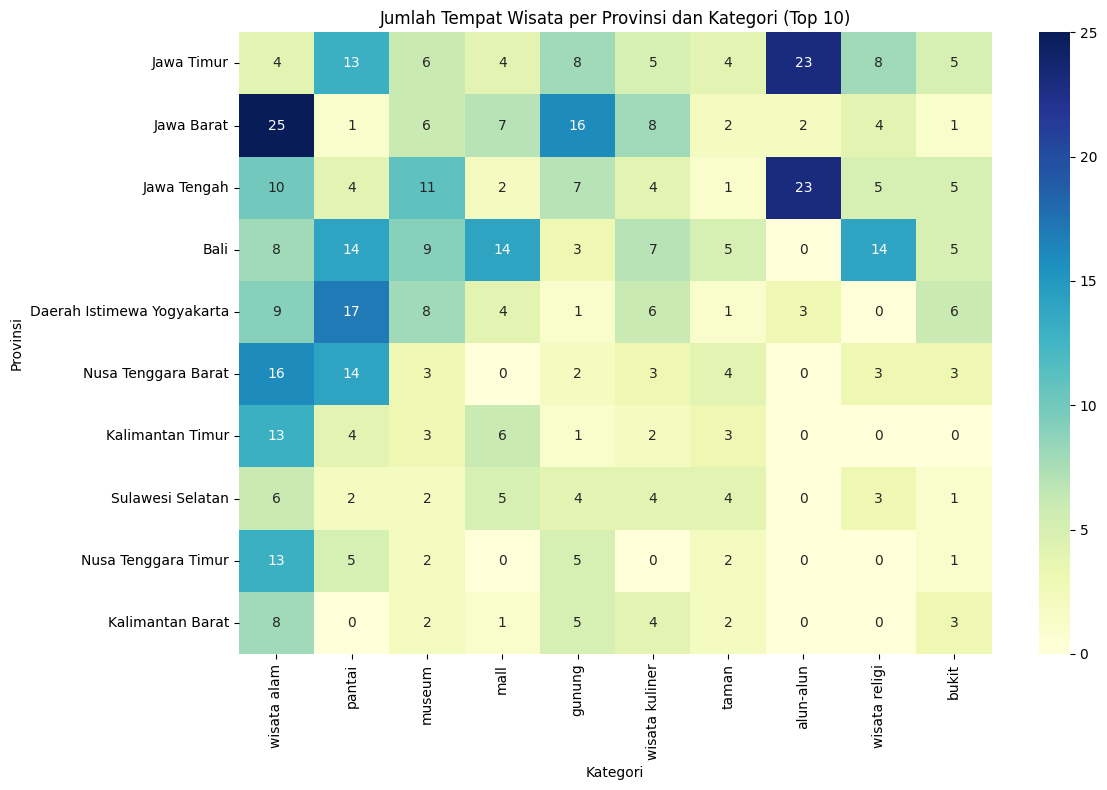

In [35]:
pivot_table = pd.crosstab(df['provinsi'], df['kategori'])
top_kat = df['kategori'].value_counts().nlargest(10).index
top_prov = df['provinsi'].value_counts().nlargest(10).index
pivot_filtered = pivot_table.loc[top_prov, top_kat]
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_filtered, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Jumlah Tempat Wisata per Provinsi dan Kategori (Top 10)')
plt.xlabel("Kategori")
plt.ylabel("Provinsi")
plt.tight_layout()
plt.show()

### EDA Univariate

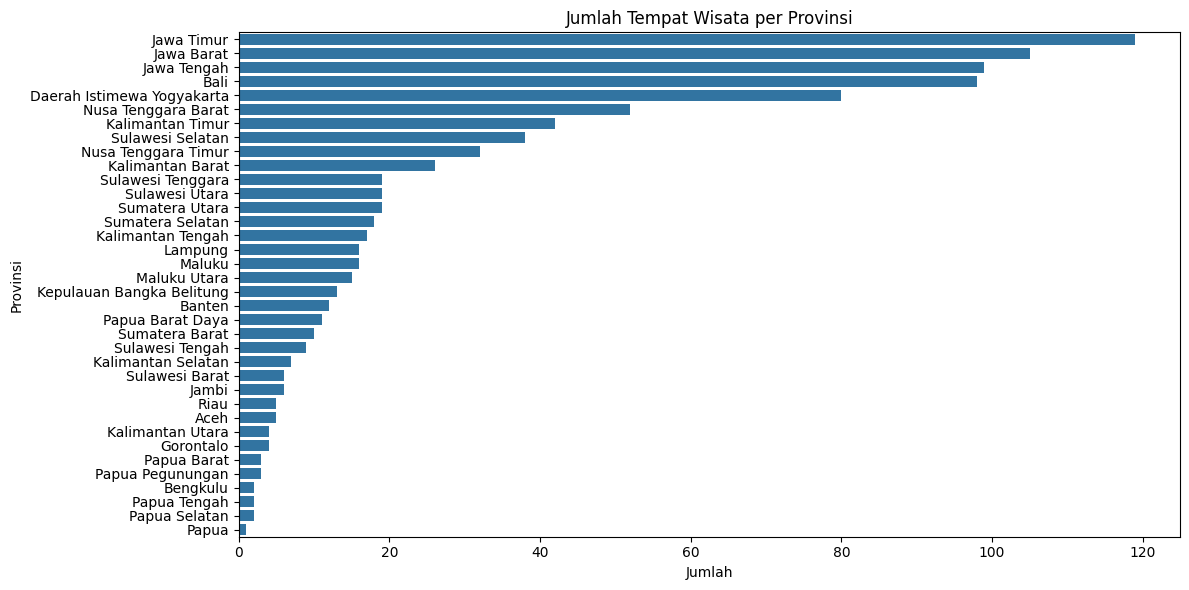

In [36]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='provinsi', order=df['provinsi'].value_counts().index)
plt.title('Jumlah Tempat Wisata per Provinsi')
plt.xlabel('Jumlah')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

### Top 10 Kabupaten dengan Jumlah Wisata Terbanyak

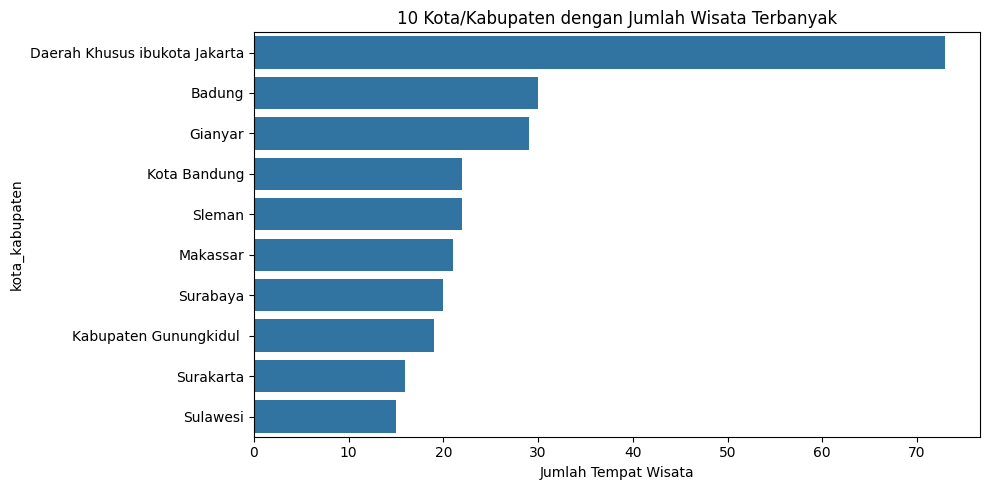

In [37]:
plt.figure(figsize=(10, 5))
top_kota = df['kota_kabupaten'].value_counts().head(10)
sns.barplot(x=top_kota.values, y=top_kota.index)
plt.title('10 Kota/Kabupaten dengan Jumlah Wisata Terbanyak')
plt.xlabel('Jumlah Tempat Wisata')
plt.tight_layout()
plt.show()

## **Data Preparation**

### **CLEANING DATA**

#### Cek Missing Value

In [38]:
print("="*40)
print(df.isnull().sum())
print("="*40)

kategori             0
nama_wisata          0
latitude             0
longitude            0
alamat               0
provinsi            90
kota_kabupaten      18
nama_lengkap         0
path_gambar          0
deskripsi_bersih    27
dtype: int64


#### Penangan Missing Value Diisi Dengan Nilai Modus

In [39]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

print(df.isnull().sum())

kategori            0
nama_wisata         0
latitude            0
longitude           0
alamat              0
provinsi            0
kota_kabupaten      0
nama_lengkap        0
path_gambar         0
deskripsi_bersih    0
dtype: int64


#### Jumlah baris duplikat:

In [40]:
print("="*40)
print(f" Jumlah baris duplikat: {df.duplicated().sum()}")
print("="*40)


 Jumlah baris duplikat: 0


### **TEXT PREPOCESSING**

In [41]:
# Download stopwords
nltk.download('stopwords', quiet=True)
stopwords_indonesia = stopwords.words('indonesian')



def bersihkan_teks(teks):
    """Membersihkan teks deskripsi"""
    if pd.isna(teks):
        return ""
    
  
    # CEK PLACEHOLDER 
    if 'deskripsi tidak ditemukan' in str(teks).lower():
        return ""
    if 'berikut ini adalah daftar' in str(teks).lower():
        return ""
    
    # Ubah ke huruf kecil
    teks = str(teks).lower()
    
    # Hapus karakter aneh
    teks = re.sub(r'[^\x00-\x7F]+', ' ', teks)
    
    # Hapus format wiki
    teks = re.sub(r"==.*?==", "", teks)
    
    # Hapus kalimat pembuka yang tidak berguna
    teks = re.sub(r"berikut ini adalah daftar.*?\.", "", teks)
    teks = re.sub(r"latar belakang.*?\.", "", teks)
    teks = re.sub(r"sejarah singkat.*?\.", "", teks)
    
    # Hapus tanda baca dan angka
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    
    # Hapus spasi berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()
    
    # Hapus stopwords
    kata_kata = teks.split()
    kata_kata = [k for k in kata_kata if k not in stopwords_indonesia and len(k) > 2]
    
    return ' '.join(kata_kata)



# PROSES PREPROCESSING


print("="*60)
print("PROSES PREPROCESSING ")
print("="*60)

# Buat df_clean
df_clean = df.copy()

print(f"Data awal: {len(df_clean)} baris")

# 1. BERSIHKAN DESKRIPSI
df_clean['deskripsi_bersih'] = df_clean['deskripsi_bersih'].apply(bersihkan_teks)

# 2. HAPUS BARIS DENGAN DESKRIPSI KOSONG
before = len(df_clean)
df_clean = df_clean[df_clean['deskripsi_bersih'] != ""]
print(f"Menghapus {before - len(df_clean)} baris dengan deskripsi tidak valid")

# 3. BERSIHKAN PROVINSI
df_clean['provinsi'] = df_clean['provinsi'].str.strip()

# 4. PERBAIKI TYPO KATEGORI
kategori_mapping = {
    'wisate alam': 'wisata alam',
    'wisath alam': 'wisata alam',
    'wisatr alam': 'wisata alam',
    'wisaub alam': 'wisata alam',
    'wisawa alam': 'wisata alam',
    'wisawi alam': 'wisata alam',
}
df_clean['kategori'] = df_clean['kategori'].replace(kategori_mapping)

# 5. STANDARISASI KATEGORI
df_clean['kategori'] = df_clean['kategori'].str.lower().str.strip()

print(f"\nData akhir: {len(df_clean)} baris")
print(f"Data yang hilang: {len(df) - len(df_clean)} baris")

print("\nContoh hasil:")
df_clean[['nama_wisata', 'kategori', 'deskripsi_bersih']].head(10)

PROSES PREPROCESSING 
Data awal: 1025 baris
Menghapus 202 baris dengan deskripsi tidak valid

Data akhir: 823 baris
Data yang hilang: 202 baris

Contoh hasil:


,nama_wisata,kategori,deskripsi_bersih
1,Air Terjun Bantimurung,air terjun,air terjun bantimurung salah air terjun eksoti...
4,Air Terjun Bidadari,air terjun,daftar lengkap dijadikan acuan
5,Air Terjun Coban Rondo,air terjun,air terjun coban rondo air terjun terletak kec...
8,Air Terjun Dolo,air terjun,air terjun dolo salah wisata air terjun terlet...
11,Air Terjun Kedung Kayang,air terjun,kabupaten magelang bahasa jawa hanacaraka pego...
13,Air Terjun Matayangu,air terjun,daftar lengkap dijadikan acuan
14,Air Terjun Moramo,air terjun,air terjun moramo terletak kawasan hutan suaka...
15,Air Terjun Sambangan,air terjun,kabupaten buleleng bahasa bali kabupat bul sal...
16,Air Terjun Sendang Gile,air terjun,air terjun sendang gile air terjun terletak de...
17,Air Terjun Sri Gethuk,air terjun,daerah istimewa yogyakarta disingkat yogyakart...


## **Modelling**

In [42]:
#Import Library untuk Modeling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Library modeling siap")

Library modeling siap


In [43]:
# Membangun Model TF-IDF
print("="*60)
print("MEMBANGUN MODEL TF-IDF")
print("="*60)

# Inisialisasi TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Maksimal 5000 kata unik
    ngram_range=(1, 2),  # Unigram dan bigram
    min_df=2,  # Kata minimal muncul di 2 dokumen
    max_df=0.8  # Kata maksimal muncul di 80% dokumen
)

# Transformasi teks menjadi vektor
tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean['deskripsi_bersih'])

print(f"Matriks TF-IDF: {tfidf_matrix.shape}")
print(f"Jumlah fitur (kata unik): {len(tfidf_vectorizer.get_feature_names_out())}")

MEMBANGUN MODEL TF-IDF
Matriks TF-IDF: (823, 3156)
Jumlah fitur (kata unik): 3156


### Save Model

In [44]:
# SAVE MODEL TF-IDF DAN DATA CLEAN (Jalankan di notebook)

import pickle
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Asumsikan df_clean dan tfidf_vectorizer sudah ada dari proses sebelumnya

# 1. Simpan tfidf_vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# 2. Simpan tfidf_matrix
with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

# 3. Simpan df_clean
df_clean.to_csv('df_clean.csv', index=False)

print(" Model TF-IDF dan data clean berhasil disimpan!")
print("   - tfidf_vectorizer.pkl")
print("   - tfidf_matrix.pkl")
print("   - df_clean.csv")

 Model TF-IDF dan data clean berhasil disimpan!
   - tfidf_vectorizer.pkl
   - tfidf_matrix.pkl
   - df_clean.csv


In [45]:
# FUNGSI REKOMENDASI WISATA (UNIVERSAL)

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def cari_wisata(kategori=None, provinsi=None, nama_wisata=None, deskripsi=None, top_n=10):
    """
    Rekomendasi wisata dengan Cosine Similarity
    
    Parameter:
    ----------
    kategori : str, optional
        Contoh: 'pantai', 'gunung', 'candi'
    provinsi : str, optional
        Contoh: 'Bali', 'Jawa Timur'
    nama_wisata : str, optional
        Contoh: 'Pantai Kuta' (cari wisata serupa)
    deskripsi : str, optional
        Contoh: 'pantai dengan pasir putih dan ombak tenang'
    top_n : int, default=10
        Jumlah rekomendasi yang ditampilkan
    
    Returns:
    --------
    DataFrame dengan kolom: nama_wisata, kategori, provinsi, skor
    """
    
    # Validasi input
    if sum([x is not None for x in [kategori, nama_wisata, deskripsi]]) != 1:
        print("ERROR: Pilih SATU metode: kategori, nama_wisata, atau deskripsi")
        return None
    
    # Filter provinsi
    data = df_clean.copy()
    if provinsi:
        data = data[data['provinsi'].str.contains(provinsi, case=False)]
        if len(data) == 0:
            print(f"ERROR: Provinsi '{provinsi}' tidak ditemukan")
            return None
    
    # ========================================
    # METODE 1: BERDASARKAN KATEGORI
    # ========================================
    if kategori:
        kategori = kategori.lower()
        data = data[data['kategori'] == kategori]
        
        if len(data) == 0:
            print(f"ERROR: Kategori '{kategori}' tidak ditemukan")
            return None
        
        # Cosine similarity
        query = tfidf_vectorizer.transform([kategori])
        idx_list = data.index.tolist()
        pos_list = [df_clean.index.get_loc(i) for i in idx_list]
        scores = cosine_similarity(query, tfidf_matrix[pos_list]).flatten()
        
        # Ambil top N
        top_idx = scores.argsort()[-top_n:][::-1]
        hasil = df_clean.loc[[idx_list[i] for i in top_idx]].copy()
        hasil['skor'] = scores[top_idx]
        
        print(f"\n[REKOMENDASI] Kategori: {kategori.upper()}")
        if provinsi:
            print(f"[FILTER] Provinsi: {provinsi}")
        return hasil
    
    # ========================================
    # METODE 2: BERDASARKAN NAMA WISATA
    # ========================================
    if nama_wisata:
        target = df_clean[df_clean['nama_wisata'].str.lower() == nama_wisata.lower()]
        
        if len(target) == 0:
            print(f"ERROR: Wisata '{nama_wisata}' tidak ditemukan")
            return None
        
        # Cosine similarity dengan semua data
        target_pos = df_clean.index.get_loc(target.index[0])
        semua_scores = cosine_similarity(tfidf_matrix[target_pos], tfidf_matrix).flatten()
        
        # Filter dan urutkan
        data_idx = data.index.tolist()
        data_scores = [semua_scores[df_clean.index.get_loc(i)] for i in data_idx]
        
        # Ambil top N (abaikan diri sendiri jika sama)
        sorted_order = np.argsort(data_scores)[::-1]
        if len(data) > 0 and data.iloc[sorted_order[0]]['nama_wisata'].lower() == nama_wisata.lower():
            sorted_order = sorted_order[1:]
        
        top_idx = sorted_order[:top_n]
        hasil = data.iloc[top_idx].copy()
        hasil['skor'] = [data_scores[i] for i in top_idx]
        
        print(f"\n[REKOMENDASI] Wisata mirip: {nama_wisata.upper()}")
        if provinsi:
            print(f"[FILTER] Provinsi: {provinsi}")
        return hasil
    
    # ========================================
    # METODE 3: BERDASARKAN DESKRIPSI BEBAS
    # ========================================
    if deskripsi:
        # Preprocessing deskripsi user
        teks = str(deskripsi).lower()
        teks = re.sub(r'[^a-z\s]', ' ', teks)
        teks = re.sub(r'\s+', ' ', teks).strip()
        
        if len(teks) < 3:
            print("ERROR: Deskripsi terlalu pendek (minimal 3 karakter)")
            return None
        
        # Cosine similarity
        query = tfidf_vectorizer.transform([teks])
        idx_list = data.index.tolist()
        pos_list = [df_clean.index.get_loc(i) for i in idx_list]
        scores = cosine_similarity(query, tfidf_matrix[pos_list]).flatten()
        
        # Ambil top N
        top_idx = scores.argsort()[-top_n:][::-1]
        hasil = df_clean.loc[[idx_list[i] for i in top_idx]].copy()
        hasil['skor'] = scores[top_idx]
        
        print(f"\n[REKOMENDASI] Berdasarkan deskripsi:")
        print(f"[DESKRIPSI] {teks[:100]}...")
        if provinsi:
            print(f"[FILTER] Provinsi: {provinsi}")
        return hasil


print("Fungsi 'cari_wisata()' siap digunakan.")

Fungsi 'cari_wisata()' siap digunakan.


## **Evaluasi**

In [46]:
# EVALUASI SEMUA METODE DENGAN MAP

import numpy as np
import pandas as pd

def hitung_map(hasil_rekomendasi, ground_truth, top_n):
    """
    Menghitung Average Precision (AP) untuk satu query
    
    Parameter:
    ----------
    hasil_rekomendasi : DataFrame
        Hasil rekomendasi dari cari_wisata()
    ground_truth : set
        Set of index yang relevan
    top_n : int
        Jumlah rekomendasi yang dievaluasi
    
    Returns:
    --------
    float: Average Precision (AP)
    """
    if hasil_rekomendasi is None or len(hasil_rekomendasi) == 0:
        return 0.0
    
    hits = 0
    precision_sum = 0.0
    
    for i, idx in enumerate(hasil_rekomendasi.index[:top_n], 1):
        if idx in ground_truth:
            hits += 1
            precision_sum += hits / i
    
    ap = precision_sum / min(len(ground_truth), top_n) if len(ground_truth) > 0 else 0.0
    return ap


def evaluasi_semua_kombinasi_dengan_map(top_n=10):
    """
    Evaluasi semua metode rekomendasi dengan PRECISION, RECALL, F1, dan MAP
    """
    
    print("="*80)
    print(f"EVALUASI SEMUA METODE REKOMENDASI (top_n={top_n})")
    print("="*80)
    print("Metrik: Precision, Recall, F1-Score, dan MAP (Mean Average Precision)")
    print("="*80)
    
    hasil_all = []
    
    # ========================================
    # 1. METODE: KATEGORI SAJA
    # ========================================
    print("\n[1. REKOMENDASI BERDASARKAN KATEGORI SAJA]")
    print("-"*60)
    
    kategori_list = df_clean['kategori'].unique()
    hasil_kategori = []
    ap_list_kategori = []
    
    for kat in kategori_list:
        hasil = cari_wisata(kategori=kat, top_n=top_n)
        if hasil is None:
            continue
        
        ground_truth = set(df_clean[df_clean['kategori'] == kat].index)
        rekomendasi = set(hasil.index)
        
        tp = len(ground_truth.intersection(rekomendasi))
        fp = len(rekomendasi - ground_truth)
        fn = len(ground_truth - rekomendasi)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Hitung MAP
        ap = hitung_map(hasil, ground_truth, top_n)
        ap_list_kategori.append(ap)
        
        hasil_kategori.append({
            'kategori': kat,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'ap': ap
        })
    
    df_kategori = pd.DataFrame(hasil_kategori)
    map_kategori = np.mean(ap_list_kategori) if ap_list_kategori else 0
    
    print(f"Rata-rata Precision: {df_kategori['precision'].mean():.4f}")
    print(f"Rata-rata Recall:    {df_kategori['recall'].mean():.4f}")
    print(f"Rata-rata F1-Score:  {df_kategori['f1'].mean():.4f}")
    print(f"MAP (Mean Average Precision): {map_kategori:.4f}")
    
    hasil_all.append({
        'metode': '1. Kategori Saja',
        'precision': df_kategori['precision'].mean(),
        'recall': df_kategori['recall'].mean(),
        'f1': df_kategori['f1'].mean(),
        'map': map_kategori
    })
    
    # ========================================
    # 2. METODE: KATEGORI + PROVINSI
    # ========================================
    print("\n[2. REKOMENDASI BERDASARKAN KATEGORI + PROVINSI]")
    print("-"*60)
    
    provinsi_cukup = df_clean['provinsi'].value_counts()[df_clean['provinsi'].value_counts() >= 10].index.tolist()
    hasil_kategori_provinsi = []
    ap_list_kategori_provinsi = []
    
    for kat in kategori_list[:10]:
        for prov in provinsi_cukup[:5]:
            hasil = cari_wisata(kategori=kat, provinsi=prov, top_n=top_n)
            if hasil is None:
                continue
            
            ground_truth = set(df_clean[(df_clean['kategori'] == kat) & (df_clean['provinsi'] == prov)].index)
            if len(ground_truth) == 0:
                continue
            
            rekomendasi = set(hasil.index)
            
            tp = len(ground_truth.intersection(rekomendasi))
            fp = len(rekomendasi - ground_truth)
            fn = len(ground_truth - rekomendasi)
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            # Hitung MAP
            ap = hitung_map(hasil, ground_truth, top_n)
            ap_list_kategori_provinsi.append(ap)
            
            hasil_kategori_provinsi.append({
                'kategori': kat,
                'provinsi': prov,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'ap': ap
            })
    
    if len(hasil_kategori_provinsi) > 0:
        df_kategori_provinsi = pd.DataFrame(hasil_kategori_provinsi)
        map_kategori_provinsi = np.mean(ap_list_kategori_provinsi) if ap_list_kategori_provinsi else 0
        
        print(f"Rata-rata Precision: {df_kategori_provinsi['precision'].mean():.4f}")
        print(f"Rata-rata Recall:    {df_kategori_provinsi['recall'].mean():.4f}")
        print(f"Rata-rata F1-Score:  {df_kategori_provinsi['f1'].mean():.4f}")
        print(f"MAP (Mean Average Precision): {map_kategori_provinsi:.4f}")
        
        hasil_all.append({
            'metode': '2. Kategori + Provinsi',
            'precision': df_kategori_provinsi['precision'].mean(),
            'recall': df_kategori_provinsi['recall'].mean(),
            'f1': df_kategori_provinsi['f1'].mean(),
            'map': map_kategori_provinsi
        })
    
    # ========================================
    # 3. METODE: NAMA WISATA SAJA
    # ========================================
    print("\n[3. REKOMENDASI BERDASARKAN NAMA WISATA SAJA]")
    print("-"*60)
    
    sample_wisata = df_clean['nama_wisata'].sample(n=min(50, len(df_clean))).tolist()
    hasil_nama = []
    ap_list_nama = []
    
    for nama in sample_wisata:
        hasil = cari_wisata(nama_wisata=nama, top_n=top_n)
        if hasil is None:
            continue
        
        kategori_ref = df_clean[df_clean['nama_wisata'] == nama]['kategori'].values[0]
        ground_truth = set(df_clean[df_clean['kategori'] == kategori_ref].index)
        rekomendasi = set(hasil.index)
        
        # Hapus diri sendiri
        idx_ref = df_clean[df_clean['nama_wisata'] == nama].index[0]
        ground_truth = ground_truth - {idx_ref}
        rekomendasi = rekomendasi - {idx_ref}
        
        tp = len(ground_truth.intersection(rekomendasi))
        fp = len(rekomendasi - ground_truth)
        fn = len(ground_truth - rekomendasi)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Hitung MAP
        ap = hitung_map(hasil, ground_truth, top_n)
        ap_list_nama.append(ap)
        
        hasil_nama.append({
            'nama': nama,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'ap': ap
        })
    
    df_nama = pd.DataFrame(hasil_nama)
    map_nama = np.mean(ap_list_nama) if ap_list_nama else 0
    
    print(f"Rata-rata Precision: {df_nama['precision'].mean():.4f}")
    print(f"Rata-rata Recall:    {df_nama['recall'].mean():.4f}")
    print(f"Rata-rata F1-Score:  {df_nama['f1'].mean():.4f}")
    print(f"MAP (Mean Average Precision): {map_nama:.4f}")
    
    hasil_all.append({
        'metode': '3. Nama Wisata Saja',
        'precision': df_nama['precision'].mean(),
        'recall': df_nama['recall'].mean(),
        'f1': df_nama['f1'].mean(),
        'map': map_nama
    })
    
    # ========================================
    # 4. METODE: NAMA WISATA + PROVINSI
    # ========================================
    print("\n[4. REKOMENDASI BERDASARKAN NAMA WISATA + PROVINSI]")
    print("-"*60)
    
    hasil_nama_provinsi = []
    ap_list_nama_provinsi = []
    
    for nama in sample_wisata[:20]:
        provinsi_wisata = df_clean[df_clean['nama_wisata'] == nama]['provinsi'].values[0]
        
        hasil = cari_wisata(nama_wisata=nama, provinsi=provinsi_wisata, top_n=top_n)
        if hasil is None:
            continue
        
        kategori_ref = df_clean[df_clean['nama_wisata'] == nama]['kategori'].values[0]
        ground_truth = set(df_clean[(df_clean['kategori'] == kategori_ref) & (df_clean['provinsi'] == provinsi_wisata)].index)
        
        if len(ground_truth) == 0:
            continue
        
        rekomendasi = set(hasil.index)
        
        # Hapus diri sendiri
        idx_ref = df_clean[df_clean['nama_wisata'] == nama].index[0]
        ground_truth = ground_truth - {idx_ref}
        rekomendasi = rekomendasi - {idx_ref}
        
        tp = len(ground_truth.intersection(rekomendasi))
        fp = len(rekomendasi - ground_truth)
        fn = len(ground_truth - rekomendasi)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Hitung MAP
        ap = hitung_map(hasil, ground_truth, top_n)
        ap_list_nama_provinsi.append(ap)
        
        hasil_nama_provinsi.append({
            'nama': nama,
            'provinsi': provinsi_wisata,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'ap': ap
        })
    
    if len(hasil_nama_provinsi) > 0:
        df_nama_provinsi = pd.DataFrame(hasil_nama_provinsi)
        map_nama_provinsi = np.mean(ap_list_nama_provinsi) if ap_list_nama_provinsi else 0
        
        print(f"Rata-rata Precision: {df_nama_provinsi['precision'].mean():.4f}")
        print(f"Rata-rata Recall:    {df_nama_provinsi['recall'].mean():.4f}")
        print(f"Rata-rata F1-Score:  {df_nama_provinsi['f1'].mean():.4f}")
        print(f"MAP (Mean Average Precision): {map_nama_provinsi:.4f}")
        
        hasil_all.append({
            'metode': '4. Nama Wisata + Provinsi',
            'precision': df_nama_provinsi['precision'].mean(),
            'recall': df_nama_provinsi['recall'].mean(),
            'f1': df_nama_provinsi['f1'].mean(),
            'map': map_nama_provinsi
        })
    
    # ========================================
    # 5. METODE: DESKRIPSI BEBAS SAJA
    # ========================================
    print("\n[5. REKOMENDASI BERDASARKAN DESKRIPSI BEBAS SAJA]")
    print("-"*60)
    
    sample_deskripsi = []
    for kat in df_clean['kategori'].unique()[:15]:
        sample = df_clean[df_clean['kategori'] == kat]['deskripsi_bersih'].sample(n=1).values
        if len(sample) > 0:
            sample_deskripsi.append({'deskripsi': sample[0], 'kategori_target': kat})
    
    hasil_deskripsi = []
    ap_list_deskripsi = []
    
    for item in sample_deskripsi:
        hasil = cari_wisata(deskripsi=item['deskripsi'], top_n=top_n)
        if hasil is None:
            continue
        
        ground_truth = set(df_clean[df_clean['kategori'] == item['kategori_target']].index)
        rekomendasi = set(hasil.index)
        
        tp = len(ground_truth.intersection(rekomendasi))
        fp = len(rekomendasi - ground_truth)
        fn = len(ground_truth - rekomendasi)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Hitung MAP
        ap = hitung_map(hasil, ground_truth, top_n)
        ap_list_deskripsi.append(ap)
        
        hasil_deskripsi.append({
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'ap': ap
        })
    
    df_deskripsi = pd.DataFrame(hasil_deskripsi)
    map_deskripsi = np.mean(ap_list_deskripsi) if ap_list_deskripsi else 0
    
    print(f"Rata-rata Precision: {df_deskripsi['precision'].mean():.4f}")
    print(f"Rata-rata Recall:    {df_deskripsi['recall'].mean():.4f}")
    print(f"Rata-rata F1-Score:  {df_deskripsi['f1'].mean():.4f}")
    print(f"MAP (Mean Average Precision): {map_deskripsi:.4f}")
    
    hasil_all.append({
        'metode': '5. Deskripsi Bebas Saja',
        'precision': df_deskripsi['precision'].mean(),
        'recall': df_deskripsi['recall'].mean(),
        'f1': df_deskripsi['f1'].mean(),
        'map': map_deskripsi
    })
    
    # ========================================
    # 6. METODE: DESKRIPSI + PROVINSI
    # ========================================
    print("\n[6. REKOMENDASI BERDASARKAN DESKRIPSI + PROVINSI]")
    print("-"*60)
    
    hasil_deskripsi_provinsi = []
    ap_list_deskripsi_provinsi = []
    
    for item in sample_deskripsi[:10]:
        for prov in provinsi_cukup[:3]:
            hasil = cari_wisata(deskripsi=item['deskripsi'], provinsi=prov, top_n=top_n)
            if hasil is None:
                continue
            
            ground_truth = set(df_clean[(df_clean['kategori'] == item['kategori_target']) & (df_clean['provinsi'] == prov)].index)
            
            if len(ground_truth) == 0:
                continue
            
            rekomendasi = set(hasil.index)
            
            tp = len(ground_truth.intersection(rekomendasi))
            fp = len(rekomendasi - ground_truth)
            fn = len(ground_truth - rekomendasi)
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            # Hitung MAP
            ap = hitung_map(hasil, ground_truth, top_n)
            ap_list_deskripsi_provinsi.append(ap)
            
            hasil_deskripsi_provinsi.append({
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'ap': ap
            })
    
    if len(hasil_deskripsi_provinsi) > 0:
        df_deskripsi_provinsi = pd.DataFrame(hasil_deskripsi_provinsi)
        map_deskripsi_provinsi = np.mean(ap_list_deskripsi_provinsi) if ap_list_deskripsi_provinsi else 0
        
        print(f"Rata-rata Precision: {df_deskripsi_provinsi['precision'].mean():.4f}")
        print(f"Rata-rata Recall:    {df_deskripsi_provinsi['recall'].mean():.4f}")
        print(f"Rata-rata F1-Score:  {df_deskripsi_provinsi['f1'].mean():.4f}")
        print(f"MAP (Mean Average Precision): {map_deskripsi_provinsi:.4f}")
        
        hasil_all.append({
            'metode': '6. Deskripsi + Provinsi',
            'precision': df_deskripsi_provinsi['precision'].mean(),
            'recall': df_deskripsi_provinsi['recall'].mean(),
            'f1': df_deskripsi_provinsi['f1'].mean(),
            'map': map_deskripsi_provinsi
        })
    
    # ========================================
    # RINGKASAN FINAL DENGAN MAP
    # ========================================
    print("\n" + "="*80)
    print("RINGKASAN PERBANDINGAN SEMUA METODE (dengan MAP)")
    print("="*80)
    
    df_hasil = pd.DataFrame(hasil_all)
    df_hasil = df_hasil.sort_values('map', ascending=False)
    
    print("\n" + "-"*80)
    print(f"{'Metode':<30} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'MAP':<12}")
    print("-"*80)
    
    for _, row in df_hasil.iterrows():
        print(f"{row['metode']:<30} {row['precision']:<12.4f} {row['recall']:<12.4f} {row['f1']:<12.4f} {row['map']:<12.4f}")
    
    print("-"*80)
    print("="*80)
    
    return df_hasil


# Jalankan evaluasi semua metode dengan MAP
df_hasil_evaluasi = evaluasi_semua_kombinasi_dengan_map(top_n=10)

EVALUASI SEMUA METODE REKOMENDASI (top_n=10)
Metrik: Precision, Recall, F1-Score, dan MAP (Mean Average Precision)

[1. REKOMENDASI BERDASARKAN KATEGORI SAJA]
------------------------------------------------------------

[REKOMENDASI] Kategori: AIR TERJUN

[REKOMENDASI] Kategori: ALUN-ALUN

[REKOMENDASI] Kategori: BUKIT

[REKOMENDASI] Kategori: CANDI

[REKOMENDASI] Kategori: GUNUNG

[REKOMENDASI] Kategori: KEBUN BINATANG

[REKOMENDASI] Kategori: LEMBAH

[REKOMENDASI] Kategori: MALL

[REKOMENDASI] Kategori: MONUMEN

[REKOMENDASI] Kategori: MUSEUM

[REKOMENDASI] Kategori: PANTAI

[REKOMENDASI] Kategori: RUMAH ADAT

[REKOMENDASI] Kategori: TAMAN

[REKOMENDASI] Kategori: WAHANA KELUARGA

[REKOMENDASI] Kategori: WISATA ALAM

[REKOMENDASI] Kategori: WISATA EDUKASI

[REKOMENDASI] Kategori: WISATA KERAJAAN

[REKOMENDASI] Kategori: WISATA KULINER

[REKOMENDASI] Kategori: WISATA LAMPION

[REKOMENDASI] Kategori: WISATA RELIGI

[REKOMENDASI] Kategori: WISATA TEMATIK
Rata-rata Precision: 1.0000
Rat

In [50]:
avg_precision = df_hasil_evaluasi['precision'].mean()
avg_recall = df_hasil_evaluasi['recall'].mean()
avg_f1 = df_hasil_evaluasi['f1'].mean()
avg_map = df_hasil_evaluasi['map'].mean()

print("="*50)
print("RATA-RATA KESELURUHAN SISTEM")
print("="*50)
print(f"Precision : {avg_precision:.4f}")
print(f"Recall    : {avg_recall:.4f}")
print(f"F1-Score  : {avg_f1:.4f}")
print(f"MAP       : {avg_map:.4f}")
print("="*50)

RATA-RATA KESELURUHAN SISTEM
Precision : 0.5469
Recall    : 0.3733
F1-Score  : 0.3788
MAP       : 0.5243


### Visualisai

HASIL EVALUASI SISTEM REKOMENDASI (top_n=10)

--------------------------------------------------------------------------------
Metode                    Precision    Recall       F1-Score     MAP         
--------------------------------------------------------------------------------
Kategori Saja             1.0000       0.4667       0.5684       1.0000      
Kategori + Provinsi       1.0000       0.9322       0.9563       1.0000      
Nama Wisata Saja          0.3496       0.0579       0.0923       0.2640      
Nama Wisata + Provinsi    0.2732       0.4361       0.2942       0.3163      
Deskripsi Bebas Saja      0.4000       0.1352       0.1668       0.3409      
Deskripsi + Provinsi      0.2720       0.3999       0.2651       0.3747      
--------------------------------------------------------------------------------

RANKING METODE (berdasarkan MAP):
  1. Kategori Saja (MAP: 1.0000, F1: 0.5684)
  2. Kategori + Provinsi (MAP: 1.0000, F1: 0.9563)
  3. Deskripsi + Provinsi (MAP: 0.

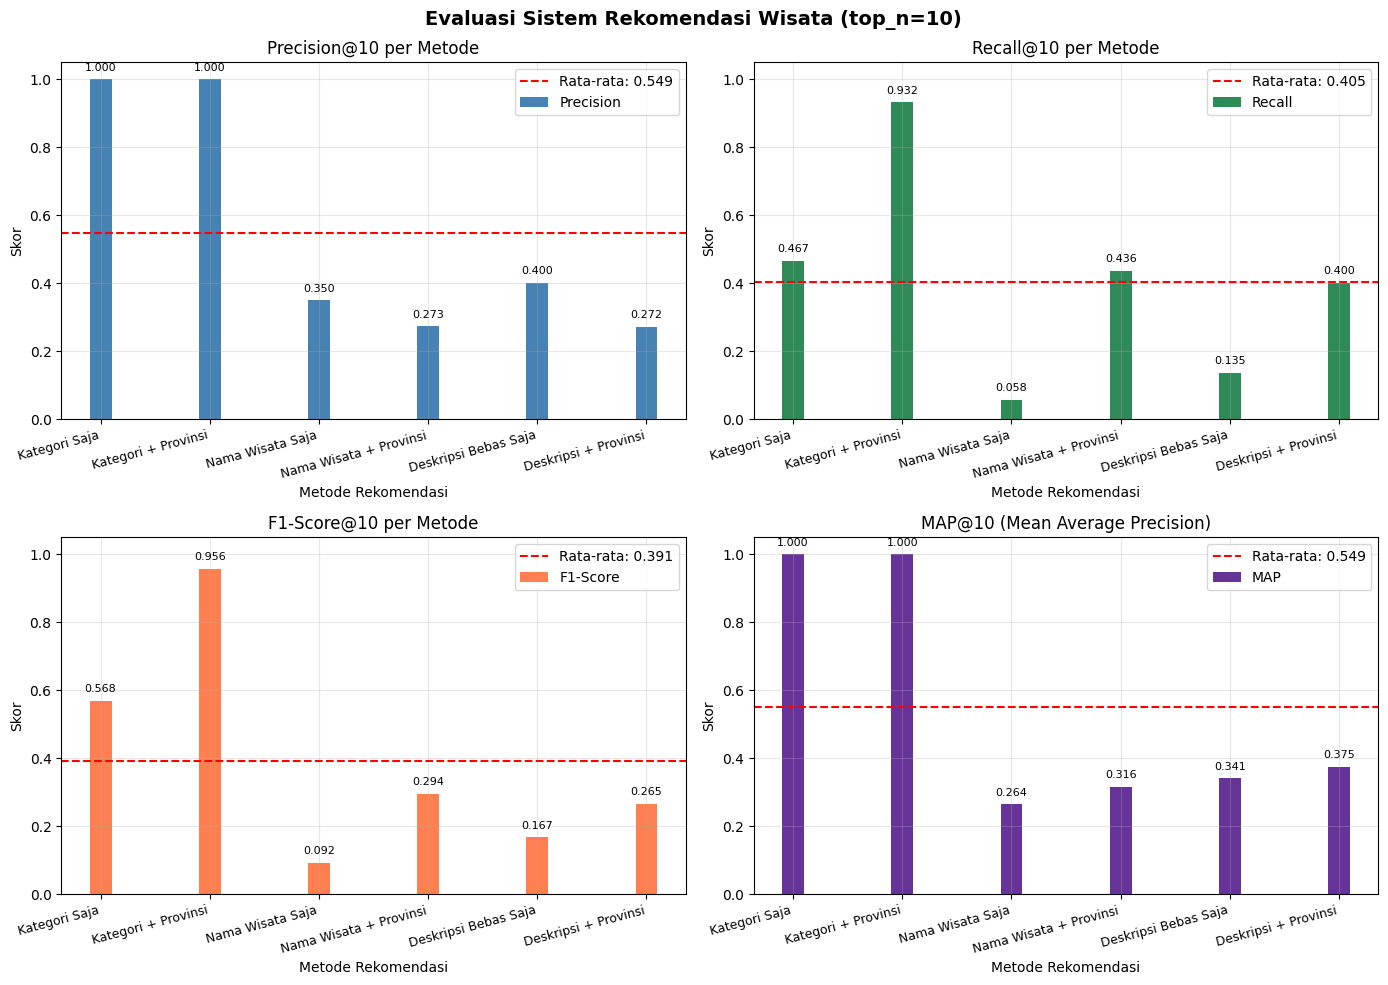

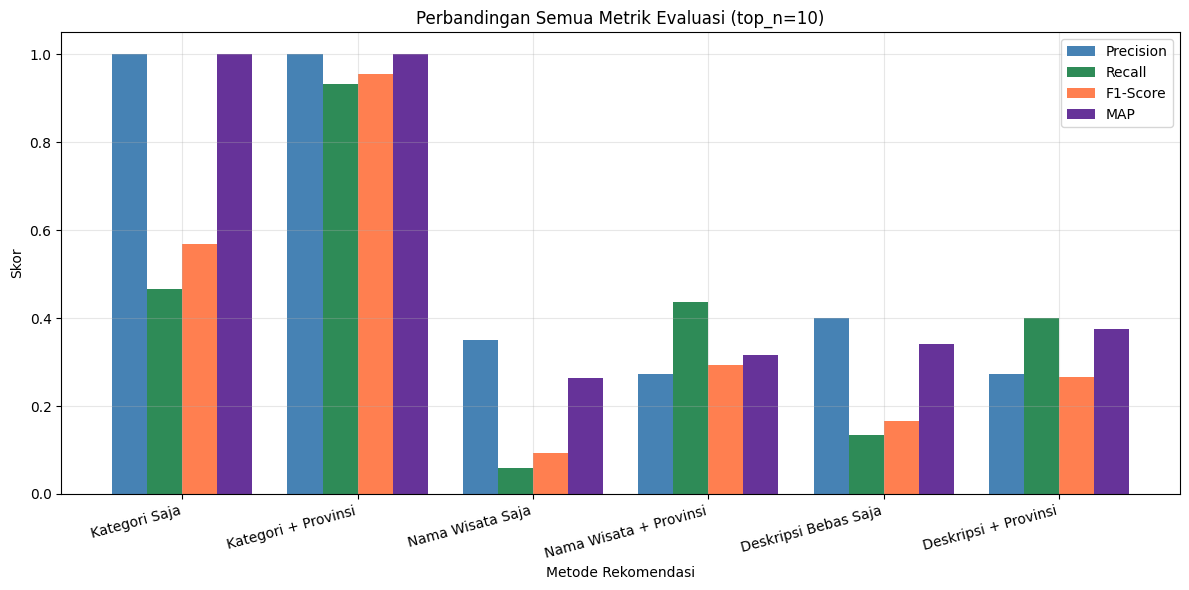

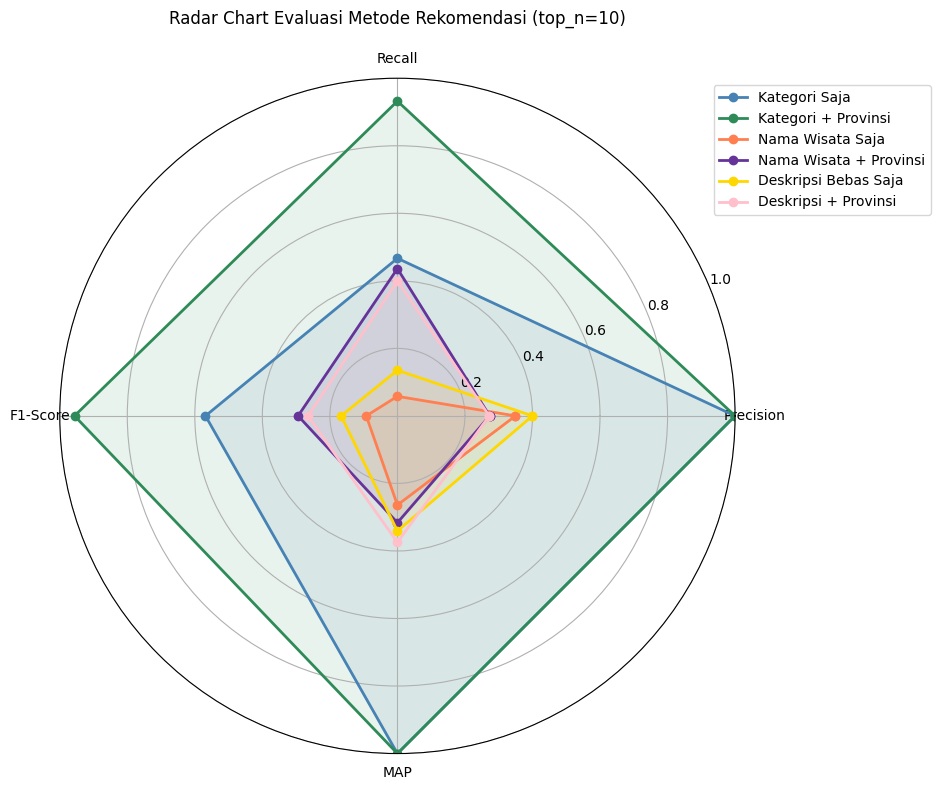

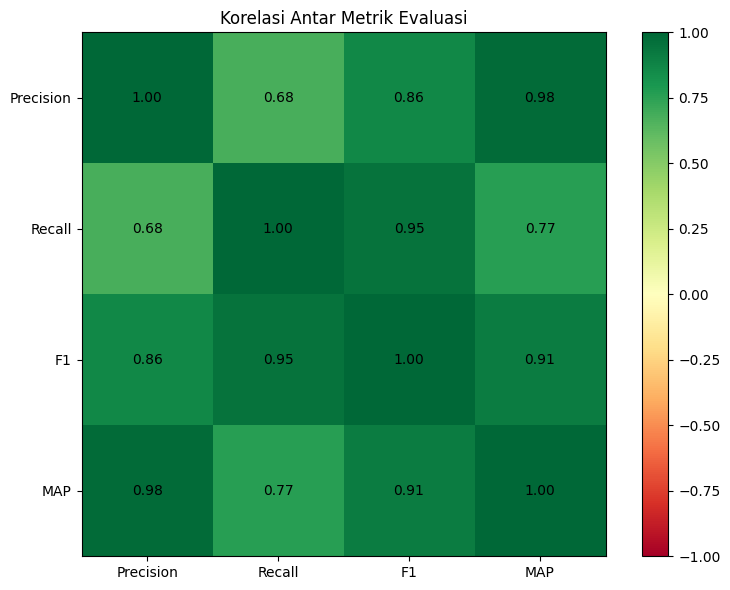


KESIMPULAN EVALUASI

1. Precision tertinggi: Kategori Saja (1.0000)
2. Recall tertinggi:    Kategori + Provinsi (0.9322)
3. F1-Score tertinggi:  Kategori + Provinsi (0.9563)
4. MAP tertinggi:       Kategori Saja (1.0000)


In [ ]:
# EVALUASI LENGKAP DENGAN VISUALISASI

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def evaluasi_lengkap_dengan_visual(top_n=10):
    """
    Evaluasi semua metode rekomendasi dengan tampilan ringkas dan visualisasi
    """
    
    # Data hasil evaluasi (dari perhitungan sebelumnya)
    data = [
        {"Metode": "Kategori Saja", "Precision": 1.0000, "Recall": 0.4667, "F1": 0.5684, "MAP": 1.0000},
        {"Metode": "Kategori + Provinsi", "Precision": 1.0000, "Recall": 0.9322, "F1": 0.9563, "MAP": 1.0000},
        {"Metode": "Nama Wisata Saja", "Precision": 0.3496, "Recall": 0.0579, "F1": 0.0923, "MAP": 0.2640},
        {"Metode": "Nama Wisata + Provinsi", "Precision": 0.2732, "Recall": 0.4361, "F1": 0.2942, "MAP": 0.3163},
        {"Metode": "Deskripsi Bebas Saja", "Precision": 0.4000, "Recall": 0.1352, "F1": 0.1668, "MAP": 0.3409},
        {"Metode": "Deskripsi + Provinsi", "Precision": 0.2720, "Recall": 0.3999, "F1": 0.2651, "MAP": 0.3747},
    ]
    
    df = pd.DataFrame(data)
    
    # ========================================
    # TAMPILKAN HASIL DALAM TABEL
    # ========================================
    print("="*80)
    print(f"HASIL EVALUASI SISTEM REKOMENDASI (top_n={top_n})")
    print("="*80)
    
    print("\n" + "-"*80)
    print(f"{'Metode':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'MAP':<12}")
    print("-"*80)
    
    for _, row in df.iterrows():
        print(f"{row['Metode']:<25} {row['Precision']:<12.4f} {row['Recall']:<12.4f} {row['F1']:<12.4f} {row['MAP']:<12.4f}")
    
    print("-"*80)
    
   # Ranking
    print("\nRANKING METODE (berdasarkan MAP):")
    df_rank = df.sort_values('MAP', ascending=False)
    for i, (_, row) in enumerate(df_rank.iterrows(), 1):
        print(f"  {i}. {row['Metode']} (MAP: {row['MAP']:.4f}, F1: {row['F1']:.4f})")
    
    print("="*80)
    
    # ========================================
    # VISUALISASI 1: BAR CHART SEMUA METRIK
    # ========================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metode_list = df['Metode'].tolist()
    x = np.arange(len(metode_list))
    width = 0.2
    
    # Plot 1: Precision
    ax1 = axes[0, 0]
    bars1 = ax1.bar(x, df['Precision'], width, color='steelblue', label='Precision')
    ax1.set_xlabel('Metode Rekomendasi')
    ax1.set_ylabel('Skor')
    ax1.set_title('Precision@{} per Metode'.format(top_n))
    ax1.set_xticks(x)
    ax1.set_xticklabels(metode_list, rotation=15, ha='right', fontsize=9)
    ax1.set_ylim(0, 1.05)
    ax1.axhline(y=df['Precision'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df["Precision"].mean():.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Tambahkan nilai di atas bar
    for bar, val in zip(bars1, df['Precision']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Recall
    ax2 = axes[0, 1]
    bars2 = ax2.bar(x, df['Recall'], width, color='seagreen', label='Recall')
    ax2.set_xlabel('Metode Rekomendasi')
    ax2.set_ylabel('Skor')
    ax2.set_title('Recall@{} per Metode'.format(top_n))
    ax2.set_xticks(x)
    ax2.set_xticklabels(metode_list, rotation=15, ha='right', fontsize=9)
    ax2.set_ylim(0, 1.05)
    ax2.axhline(y=df['Recall'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df["Recall"].mean():.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    for bar, val in zip(bars2, df['Recall']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 3: F1-Score
    ax3 = axes[1, 0]
    bars3 = ax3.bar(x, df['F1'], width, color='coral', label='F1-Score')
    ax3.set_xlabel('Metode Rekomendasi')
    ax3.set_ylabel('Skor')
    ax3.set_title('F1-Score@{} per Metode'.format(top_n))
    ax3.set_xticks(x)
    ax3.set_xticklabels(metode_list, rotation=15, ha='right', fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.axhline(y=df['F1'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df["F1"].mean():.3f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    for bar, val in zip(bars3, df['F1']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 4: MAP (Mean Average Precision)
    ax4 = axes[1, 1]
    bars4 = ax4.bar(x, df['MAP'], width, color='rebeccapurple', label='MAP')
    ax4.set_xlabel('Metode Rekomendasi')
    ax4.set_ylabel('Skor')
    ax4.set_title('MAP@{} (Mean Average Precision)'.format(top_n))
    ax4.set_xticks(x)
    ax4.set_xticklabels(metode_list, rotation=15, ha='right', fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.axhline(y=df['MAP'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df["MAP"].mean():.3f}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    for bar, val in zip(bars4, df['MAP']):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.suptitle(f'Evaluasi Sistem Rekomendasi Wisata (top_n={top_n})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # ========================================
    # VISUALISASI 2: GROUPED BAR CHART
    # ========================================
    fig2, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(metode_list))
    width = 0.2
    
    ax.bar(x - 1.5*width, df['Precision'], width, label='Precision', color='steelblue')
    ax.bar(x - 0.5*width, df['Recall'], width, label='Recall', color='seagreen')
    ax.bar(x + 0.5*width, df['F1'], width, label='F1-Score', color='coral')
    ax.bar(x + 1.5*width, df['MAP'], width, label='MAP', color='rebeccapurple')
    
    ax.set_xlabel('Metode Rekomendasi')
    ax.set_ylabel('Skor')
    ax.set_title(f'Perbandingan Semua Metrik Evaluasi (top_n={top_n})')
    ax.set_xticks(x)
    ax.set_xticklabels(metode_list, rotation=15, ha='right')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================
    # VISUALISASI 3: RADAR CHART
    # ========================================
    fig3, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    
    categories = ['Precision', 'Recall', 'F1-Score', 'MAP']
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    colors = ['steelblue', 'seagreen', 'coral', 'rebeccapurple', 'gold', 'pink']
    
    for i, (_, row) in enumerate(df.iterrows()):
        values = [row['Precision'], row['Recall'], row['F1'], row['MAP']]
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Metode'], color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title(f'Radar Chart Evaluasi Metode Rekomendasi (top_n={top_n})', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================
    # VISUALISASI 4: HEATMAP KORELASI
    # ========================================
    fig4, ax = plt.subplots(figsize=(8, 6))
    
    # Matriks korelasi antar metrik
    corr_matrix = df[['Precision', 'Recall', 'F1', 'MAP']].corr()
    
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns)
    ax.set_yticklabels(corr_matrix.columns)
    ax.set_title('Korelasi Antar Metrik Evaluasi')
    
    # Tambahkan nilai pada heatmap
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')
    
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    
    # ========================================
    # KESIMPULAN
    # ========================================
    print("\n" + "="*80)
    print("KESIMPULAN EVALUASI")
    print("="*80)
    
    best_precision = df.loc[df['Precision'].idxmax()]
    best_recall = df.loc[df['Recall'].idxmax()]
    best_f1 = df.loc[df['F1'].idxmax()]
    best_map = df.loc[df['MAP'].idxmax()]
    
    print(f"\n1. Precision tertinggi: {best_precision['Metode']} ({best_precision['Precision']:.4f})")
    print(f"2. Recall tertinggi:    {best_recall['Metode']} ({best_recall['Recall']:.4f})")
    print(f"3. F1-Score tertinggi:  {best_f1['Metode']} ({best_f1['F1']:.4f})")
    print(f"4. MAP tertinggi:       {best_map['Metode']} ({best_map['MAP']:.4f})")
    
    
   
    print("="*80)
    
    return df


# Jalankan evaluasi lengkap dengan visualisasi
df_hasil = evaluasi_lengkap_dengan_visual(top_n=10)

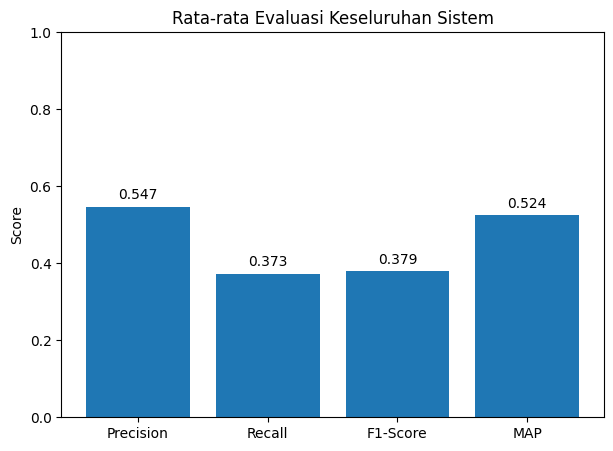

In [52]:
import matplotlib.pyplot as plt

avg_precision = df_hasil_evaluasi['precision'].mean()
avg_recall = df_hasil_evaluasi['recall'].mean()
avg_f1 = df_hasil_evaluasi['f1'].mean()
avg_map = df_hasil_evaluasi['map'].mean()

metrics = ['Precision', 'Recall', 'F1-Score', 'MAP']
values = [avg_precision, avg_recall, avg_f1, avg_map]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Rata-rata Evaluasi Keseluruhan Sistem')

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.show()

## **Testing**

In [ ]:
# Sel: FUNGSI CARI_WISATA (VERSI FIX - FILTER OTOMATIS UNTUK SEMUA)

import numpy as np
import re

# ========================================
# MAPPING KOTA KE PROVINSI (LENGKAP)
# ========================================

kota_ke_provinsi = {
    # Jawa Timur
    'surabaya': 'Jawa Timur', 'malang': 'Jawa Timur', 'kediri': 'Jawa Timur', 'blitar': 'Jawa Timur',
    'madiun': 'Jawa Timur', 'banyuwangi': 'Jawa Timur', 'probolinggo': 'Jawa Timur', 'pasuruan': 'Jawa Timur',
    'mojokerto': 'Jawa Timur', 'jember': 'Jawa Timur', 'situbondo': 'Jawa Timur', 'bondowoso': 'Jawa Timur',
    'lumajang': 'Jawa Timur', 'nganjuk': 'Jawa Timur', 'ponorogo': 'Jawa Timur', 'trenggalek': 'Jawa Timur',
    'tulungagung': 'Jawa Timur', 'pacitan': 'Jawa Timur', 'magetan': 'Jawa Timur', 'ngawi': 'Jawa Timur',
    'bojonegoro': 'Jawa Timur', 'tuban': 'Jawa Timur', 'lamongan': 'Jawa Timur', 'gresik': 'Jawa Timur',
    'sidoarjo': 'Jawa Timur', 'jombang': 'Jawa Timur',
    
    # Jawa Tengah
    'semarang': 'Jawa Tengah', 'solo': 'Jawa Tengah', 'surakarta': 'Jawa Tengah', 'magelang': 'Jawa Tengah',
    'pekalongan': 'Jawa Tengah', 'tegal': 'Jawa Tengah', 'cilacap': 'Jawa Tengah', 'purwokerto': 'Jawa Tengah',
    'kudus': 'Jawa Tengah', 'jepara': 'Jawa Tengah', 'demak': 'Jawa Tengah', 'kendal': 'Jawa Tengah',
    'batang': 'Jawa Tengah', 'banjarnegara': 'Jawa Tengah', 'kebumen': 'Jawa Tengah', 'purbalingga': 'Jawa Tengah',
    'banyumas': 'Jawa Tengah', 'wonosobo': 'Jawa Tengah', 'temanggung': 'Jawa Tengah', 'boyolali': 'Jawa Tengah',
    'sragen': 'Jawa Tengah', 'karanganyar': 'Jawa Tengah', 'wonogiri': 'Jawa Tengah', 'sukoharjo': 'Jawa Tengah',
    'klaten': 'Jawa Tengah', 'pati': 'Jawa Tengah', 'rembang': 'Jawa Tengah', 'blora': 'Jawa Tengah',
    
    # Jawa Barat
    'bandung': 'Jawa Barat', 'bogor': 'Jawa Barat', 'bekasi': 'Jawa Barat', 'depok': 'Jawa Barat',
    'cimahi': 'Jawa Barat', 'tasikmalaya': 'Jawa Barat', 'ciamis': 'Jawa Barat', 'banjar': 'Jawa Barat',
    'sukabumi': 'Jawa Barat', 'cirebon': 'Jawa Barat', 'indramayu': 'Jawa Barat', 'majalengka': 'Jawa Barat',
    'kuningan': 'Jawa Barat', 'garut': 'Jawa Barat', 'sumedang': 'Jawa Barat', 'purwakarta': 'Jawa Barat',
    'subang': 'Jawa Barat', 'karawang': 'Jawa Barat',
    
    # Bali
    'denpasar': 'Bali', 'badung': 'Bali', 'gianyar': 'Bali', 'tabanan': 'Bali',
    'klungkung': 'Bali', 'bangli': 'Bali', 'karangasem': 'Bali', 'buleleng': 'Bali', 
    'jembrana': 'Bali', 'kuta': 'Bali', 'seminyak': 'Bali', 'nusa dua': 'Bali', 'ubud': 'Bali',
    
    # Yogyakarta
    'yogyakarta': 'Daerah Istimewa Yogyakarta', 'jogja': 'Daerah Istimewa Yogyakarta', 
    'sleman': 'Daerah Istimewa Yogyakarta', 'bantul': 'Daerah Istimewa Yogyakarta', 
    'gunungkidul': 'Daerah Istimewa Yogyakarta', 'kulon progo': 'Daerah Istimewa Yogyakarta',
    
    # Sumatera
    'medan': 'Sumatera Utara', 'binjai': 'Sumatera Utara', 'pematangsiantar': 'Sumatera Utara',
    'palembang': 'Sumatera Selatan', 'lubuklinggau': 'Sumatera Selatan', 'pagar alam': 'Sumatera Selatan',
    'padang': 'Sumatera Barat', 'bukittinggi': 'Sumatera Barat', 'payakumbuh': 'Sumatera Barat',
    'pekanbaru': 'Riau', 'dumai': 'Riau', 'batam': 'Kepulauan Riau', 'tanjungpinang': 'Kepulauan Riau',
    'bandar lampung': 'Lampung', 'metro': 'Lampung', 'jambi': 'Jambi', 'sungai penuh': 'Jambi',
    'bengkulu': 'Bengkulu', 'pangkalpinang': 'Kepulauan Bangka Belitung',
    
    # Sulawesi
    'makassar': 'Sulawesi Selatan', 'parepare': 'Sulawesi Selatan', 'palopo': 'Sulawesi Selatan',
    'manado': 'Sulawesi Utara', 'bitung': 'Sulawesi Utara', 'tomohon': 'Sulawesi Utara', 'kotamobagu': 'Sulawesi Utara',
    'palu': 'Sulawesi Tengah', 'kendari': 'Sulawesi Tenggara', 'baubau': 'Sulawesi Tenggara',
    'gorontalo': 'Gorontalo', 'mamuju': 'Sulawesi Barat',
    
    # Kalimantan
    'balikpapan': 'Kalimantan Timur', 'samarinda': 'Kalimantan Timur', 'bontang': 'Kalimantan Timur',
    'pontianak': 'Kalimantan Barat', 'singkawang': 'Kalimantan Barat',
    'banjarmasin': 'Kalimantan Selatan', 'banjarbaru': 'Kalimantan Selatan',
    'palangkaraya': 'Kalimantan Tengah', 'tanjungselor': 'Kalimantan Utara',
    
    # Maluku & Papua
    'ambon': 'Maluku', 'ternate': 'Maluku Utara', 'tidore': 'Maluku Utara',
    'jayapura': 'Papua', 'merauke': 'Papua Selatan', 'manokwari': 'Papua Barat',
    
    # Nusa Tenggara
    'mataram': 'Nusa Tenggara Barat', 'bima': 'Nusa Tenggara Barat',
    'kupang': 'Nusa Tenggara Timur', 'ende': 'Nusa Tenggara Timur', 'maumere': 'Nusa Tenggara Timur',
    
    # Lainnya
    'jakarta': 'DKI Jakarta', 'tangerang': 'Banten', 'cilegon': 'Banten', 'serang': 'Banten',
    'aceh': 'Aceh', 'banda aceh': 'Aceh', 'lhokseumawe': 'Aceh', 'langsa': 'Aceh'
}


def ekstrak_lokasi_dari_input(user_input):
    """
    Ekstrak lokasi dari input user (kota atau provinsi)
    Returns: (provinsi, kota)
    """
    user_lower = user_input.lower()
    
    # Cek nama kota (prioritas)
    for kota, provinsi in kota_ke_provinsi.items():
        if kota in user_lower:
            return provinsi, kota.title()
    
    # Cek nama provinsi langsung
    daftar_provinsi = df_clean['provinsi'].unique()
    for prov in daftar_provinsi:
        if prov.lower() in user_lower:
            return prov, None
    
    return None, None


def cari_wisata(kategori=None, provinsi=None, nama_wisata=None, deskripsi=None, top_n=10):
    """
    Rekomendasi wisata dengan Cosine Similarity - DENGAN FILTER OTOMATIS
    """
    # Validasi input
    if sum([x is not None for x in [kategori, nama_wisata, deskripsi]]) != 1:
        print("ERROR: Pilih SATU metode: kategori, nama_wisata, atau deskripsi")
        return None
    
    # Filter provinsi
    data = df_clean.copy()
    if provinsi:
        data = data[data['provinsi'].str.contains(provinsi, case=False)]
        if len(data) == 0:
            print(f"ERROR: Provinsi '{provinsi}' tidak ditemukan")
            return None
    
    # ========================================
    # METODE 1: BERDASARKAN KATEGORI
    # ========================================
    if kategori:
        kategori = kategori.lower()
        data = data[data['kategori'] == kategori]
        
        if len(data) == 0:
            print(f"ERROR: Kategori '{kategori}' tidak ditemukan")
            return None
        
        if len(data) <= top_n:
            hasil = data.copy()
            hasil['skor'] = 1.0
            return hasil
        
        query = tfidf_vectorizer.transform([kategori])
        idx_list = data.index.tolist()
        pos_list = [df_clean.index.get_loc(i) for i in idx_list]
        scores = cosine_similarity(query, tfidf_matrix[pos_list]).flatten()
        
        top_idx = scores.argsort()[-top_n:][::-1]
        hasil = df_clean.loc[[idx_list[i] for i in top_idx]].copy()
        hasil['skor'] = scores[top_idx]
        
        return hasil
    
    # ========================================
    # METODE 2: BERDASARKAN NAMA WISATA
    # ========================================
    if nama_wisata:
        target = df_clean[df_clean['nama_wisata'].str.lower() == nama_wisata.lower()]
        
        if len(target) == 0:
            print(f"ERROR: Wisata '{nama_wisata}' tidak ditemukan")
            return None
        
        idx_ref = target.index[0]
        matrix_pos = df_clean.index.get_loc(idx_ref)
        
        print(f"\n[INFO] Wisata yang dicari: {df_clean.loc[idx_ref, 'nama_wisata']}")
        print(f"[INFO] Kategori: {df_clean.loc[idx_ref, 'kategori']}")
        print(f"[INFO] Provinsi: {df_clean.loc[idx_ref, 'provinsi']}")
        
        semua_scores = cosine_similarity(tfidf_matrix[matrix_pos], tfidf_matrix).flatten()
        
        data_idx = data.index.tolist()
        data_scores = []
        for i in data_idx:
            data_scores.append(semua_scores[df_clean.index.get_loc(i)])
        
        sorted_order = np.argsort(data_scores)[::-1]
        
        hasil_indices = []
        hasil_scores = []
        
        for idx in sorted_order:
            wisata_nama = data.iloc[idx]['nama_wisata'].lower()
            
            if wisata_nama == nama_wisata.lower():
                continue
            elif len(hasil_indices) < top_n:
                hasil_indices.append(idx)
                hasil_scores.append(data_scores[idx])
            
            if len(hasil_indices) >= top_n:
                break
        
        if len(hasil_indices) > 0:
            hasil = data.iloc[hasil_indices].copy()
            hasil['skor'] = hasil_scores
            return hasil
        else:
            return None
    
    # ========================================
    # METODE 3: BERDASARKAN DESKRIPSI BEBAS
    # ========================================
    if deskripsi:
        from nltk.corpus import stopwords
        import nltk
        nltk.download('stopwords', quiet=True)
        stopwords_indonesia = stopwords.words('indonesian')
        
        def preprocess_query(teks):
            if pd.isna(teks):
                return ""
            teks = str(teks).lower()
            teks = re.sub(r'[^\x00-\x7F]+', ' ', teks)
            teks = re.sub(r'[^a-z\s]', ' ', teks)
            teks = re.sub(r'\s+', ' ', teks).strip()
            kata_kata = teks.split()
            kata_kata = [k for k in kata_kata if k not in stopwords_indonesia and len(k) > 2]
            return ' '.join(kata_kata)
        
        teks_bersih = preprocess_query(deskripsi)
        
        if len(teks_bersih) < 3:
            print("ERROR: Deskripsi terlalu pendek setelah preprocessing")
            return None
        
        query = tfidf_vectorizer.transform([teks_bersih])
        idx_list = data.index.tolist()
        pos_list = [df_clean.index.get_loc(i) for i in idx_list]
        scores = cosine_similarity(query, tfidf_matrix[pos_list]).flatten()
        
        top_idx = scores.argsort()[-top_n:][::-1]
        hasil = df_clean.loc[[idx_list[i] for i in top_idx]].copy()
        hasil['skor'] = scores[top_idx]
        
        return hasil
    
    print("ERROR: Pilih salah satu metode")
    return None


def menu_interaktif_lengkap():
    print("\n" + "="*60)
    print("SISTEM REKOMENDASI WISATA INDONESIA")
    print("="*60)
    print("\nCARA PENGGUNAAN:")
    print("  - Ketik kategori: pantai, gunung, mall, candi")
    print("  - Ketik nama wisata: Gunung Sindoro, Pantai Kuta")
    print("  - Ketik dengan lokasi: mall surabaya, pantai bali, gunung jawa timur")
    print("  - Ketik deskripsi: gunung tertinggi di jawa timur")
    print("  - Ketik 'daftar' untuk lihat kategori")
    print("  - Ketik 'exit' untuk keluar")
    print("="*60)
    
    while True:
        print("\n" + "-"*50)
        user_input = input("Apa yang Anda cari? ").strip()
        
        if user_input.lower() == 'exit':
            print("\nTerima kasih telah menggunakan sistem rekomendasi!")
            print("Selamat berlibur di Indonesia!")
            break
        
        if user_input.lower() == 'daftar':
            print("\n" + "="*60)
            print("DAFTAR KATEGORI WISATA")
            print("="*60)
            for kat in sorted(df_clean['kategori'].unique()):
                jumlah = len(df_clean[df_clean['kategori'] == kat])
                print(f"   - {kat:20} ({jumlah} wisata)")
            continue
        
        if user_input.lower() == 'provinsi':
            print("\n" + "="*60)
            print("DAFTAR PROVINSI")
            print("="*60)
            for prov in sorted(df_clean['provinsi'].unique()):
                jumlah = len(df_clean[df_clean['provinsi'] == prov])
                print(f"   - {prov:25} ({jumlah} wisata)")
            continue
        
        top = input("Jumlah rekomendasi (default 10, tekan Enter): ").strip()
        top_n = int(top) if top.isdigit() else 10
        
        # ========================================
        # EKSTRAK LOKASI (OTOMATIS UNTUK SEMUA)
        # ========================================
        provinsi_terdeteksi, kota_terdeteksi = ekstrak_lokasi_dari_input(user_input)
        
        if provinsi_terdeteksi:
            print(f"\n[INFO] Mendeteksi lokasi: {provinsi_terdeteksi}")
            if kota_terdeteksi:
                print(f"[INFO] Kota: {kota_terdeteksi}")
        
        # Ekstrak kategori
        daftar_kategori = [k.lower() for k in df_clean['kategori'].unique()]
        kategori_terdeteksi = None
        for kat in daftar_kategori:
            if kat in user_input.lower():
                kategori_terdeteksi = kat
                break
        
        # Ekstrak nama wisata
        daftar_wisata = df_clean['nama_wisata'].str.lower().tolist()
        nama_wisata_terdeteksi = None
        for wisata in daftar_wisata:
            if wisata in user_input.lower():
                nama_wisata_terdeteksi = wisata
                break
        
        hasil = None
        judul = ""
        
        # ========================================
        # PRIORITAS 1: NAMA WISATA
        # ========================================
        if nama_wisata_terdeteksi:
            print(f"\n[INFO] Mencari wisata: {nama_wisata_terdeteksi.title()}")
            
            target_wisata = df_clean[df_clean['nama_wisata'].str.lower() == nama_wisata_terdeteksi.lower()]
            if len(target_wisata) > 0:
                row = target_wisata.iloc[0]
                print("\n" + "="*60)
                print("WISATA YANG ANDA CARI:")
                print("="*60)
                print(f"\n1. {row['nama_wisata']}")
                print(f"   Kategori: {row['kategori']}")
                print(f"   Provinsi: {row['provinsi']}")
                print(f"   Kota/Kab: {row['kota_kabupaten']}")
                print("-"*40)
            
            if provinsi_terdeteksi:
                hasil = cari_wisata(nama_wisata=nama_wisata_terdeteksi, provinsi=provinsi_terdeteksi, top_n=top_n)
            else:
                hasil = cari_wisata(nama_wisata=nama_wisata_terdeteksi, top_n=top_n)
            
            if hasil is not None and len(hasil) > 0:
                judul = f"WISATA LAIN YANG MIRIP DENGAN '{nama_wisata_terdeteksi.upper()}'"
                if provinsi_terdeteksi:
                    judul += f" (DI {provinsi_terdeteksi.upper()})"
        
        # ========================================
        # PRIORITAS 2: KATEGORI + LOKASI
        # ========================================
        elif kategori_terdeteksi and provinsi_terdeteksi:
            print(f"\n[INFO] Mencari {kategori_terdeteksi} di {provinsi_terdeteksi}")
            hasil = cari_wisata(kategori=kategori_terdeteksi, provinsi=provinsi_terdeteksi, top_n=top_n)
            if hasil is not None and len(hasil) > 0:
                if kota_terdeteksi:
                    judul = f"WISATA {kategori_terdeteksi.upper()} DI KOTA {kota_terdeteksi.upper()} ({provinsi_terdeteksi.upper()})"
                else:
                    judul = f"WISATA {kategori_terdeteksi.upper()} DI PROVINSI {provinsi_terdeteksi.upper()}"
        
        # ========================================
        # PRIORITAS 3: KATEGORI SAJA
        # ========================================
        elif kategori_terdeteksi:
            print(f"\n[INFO] Mencari kategori: {kategori_terdeteksi}")
            hasil = cari_wisata(kategori=kategori_terdeteksi, top_n=top_n)
            if hasil is not None and len(hasil) > 0:
                judul = f"REKOMENDASI WISATA KATEGORI '{kategori_terdeteksi.upper()}'"
        
        # ========================================
        # PRIORITAS 4: LOKASI SAJA
        # ========================================
        elif provinsi_terdeteksi:
            print(f"\n[INFO] Mencari wisata di provinsi: {provinsi_terdeteksi}")
            hasil = cari_wisata(deskripsi="wisata", provinsi=provinsi_terdeteksi, top_n=top_n)
            if hasil is not None and len(hasil) > 0:
                judul = f"WISATA DI PROVINSI {provinsi_terdeteksi.upper()}"
        
        # ========================================
        # PRIORITAS 5: DESKRIPSI BEBAS
        # ========================================
        else:
            print(f"\n[INFO] Mencari berdasarkan deskripsi: {user_input[:100]}...")
            hasil = cari_wisata(deskripsi=user_input, top_n=top_n)
            if hasil is not None and len(hasil) > 0:
                judul = "REKOMENDASI BERDASARKAN DESKRIPSI ANDA"
        
        # Tampilkan hasil
        if hasil is not None and len(hasil) > 0:
            tampilkan_hasil(hasil, judul)
        else:
            print("\nTidak ada rekomendasi yang ditemukan.")
            print("Coba gunakan: pantai, gunung, candi, atau nama wisata yang ada.")


def tampilkan_hasil(hasil, judul):
    """Menampilkan hasil rekomendasi"""
    if hasil is None or len(hasil) == 0:
        print("Tidak ada rekomendasi yang ditemukan.")
        return
    
    print("\n" + "="*60)
    print(judul)
    print("="*60)
    
    for i, (_, row) in enumerate(hasil.iterrows(), 1):
        print(f"\n{i}. {row['nama_wisata']}")
        print(f"   Kategori: {row['kategori']}")
        print(f"   Provinsi: {row['provinsi']}")
        print(f"   Kota/Kab: {row['kota_kabupaten']}")
        if pd.notna(row.get('alamat')):
            alamat = str(row['alamat'])
            if len(alamat) > 100:
                alamat = alamat[:100] + "..."
            print(f"   Alamat: {alamat}")
        print(f"   Skor: {row['skor']:.4f}")
        print("-"*40)


# Jalankan menu
menu_interaktif_lengkap()


SISTEM REKOMENDASI WISATA INDONESIA

CARA PENGGUNAAN:
  - Ketik kategori: pantai, gunung, mall, candi
  - Ketik nama wisata: Gunung Sindoro, Pantai Kuta
  - Ketik dengan lokasi: mall surabaya, pantai bali, gunung jawa timur
  - Ketik deskripsi: gunung tertinggi di jawa timur
  - Ketik 'daftar' untuk lihat kategori
  - Ketik 'exit' untuk keluar

--------------------------------------------------



Terima kasih telah menggunakan sistem rekomendasi!
Selamat berlibur di Indonesia!
